## Libraries

In [3]:
%pip install xgboost

In [4]:
import os
import kagglehub
import zipfile
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, precision_recall_curve, average_precision_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

## Kaggle Authentication

In [ ]:
# Upload Kaggle API Token for Authentication
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nixrowley","key":"KGAT_dbb3f7cb470d7d476cee2f0f9622bdf9"}\n'}

## Exploratory Data Analysis

In [5]:
# Download Dataset and Unzip
!kaggle datasets download -d nelgiriyewithana/credit-card-fraud-detection-dataset-2023

with zipfile.ZipFile('credit-card-fraud-detection-dataset-2023.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023
License(s): other
100% 143M/143M [00:01<00:00, 89.5MB/s]



In [6]:
# Load into Pandas and Inspect
df_cc_fraud = pd.read_csv('/content/creditcard_2023.csv')  # adjust filename if needed
print(f"Original Dataset Shape: {df_cc_fraud.shape}")
df_cc_fraud.head()

Original Dataset Shape: (568630, 31)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

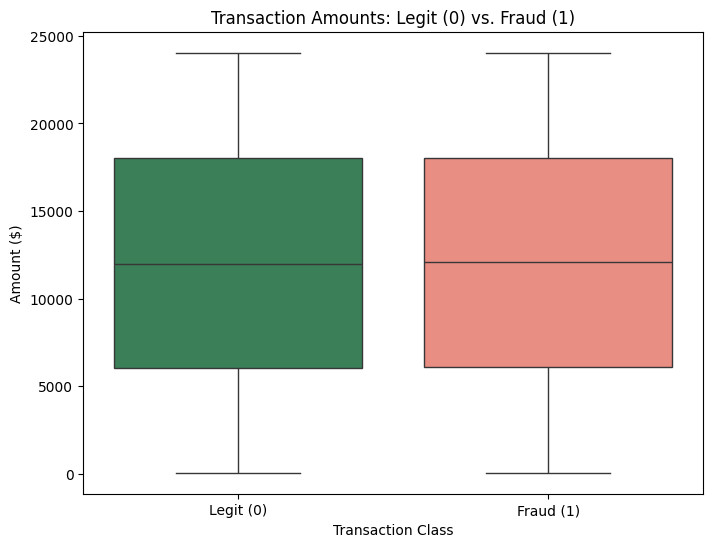

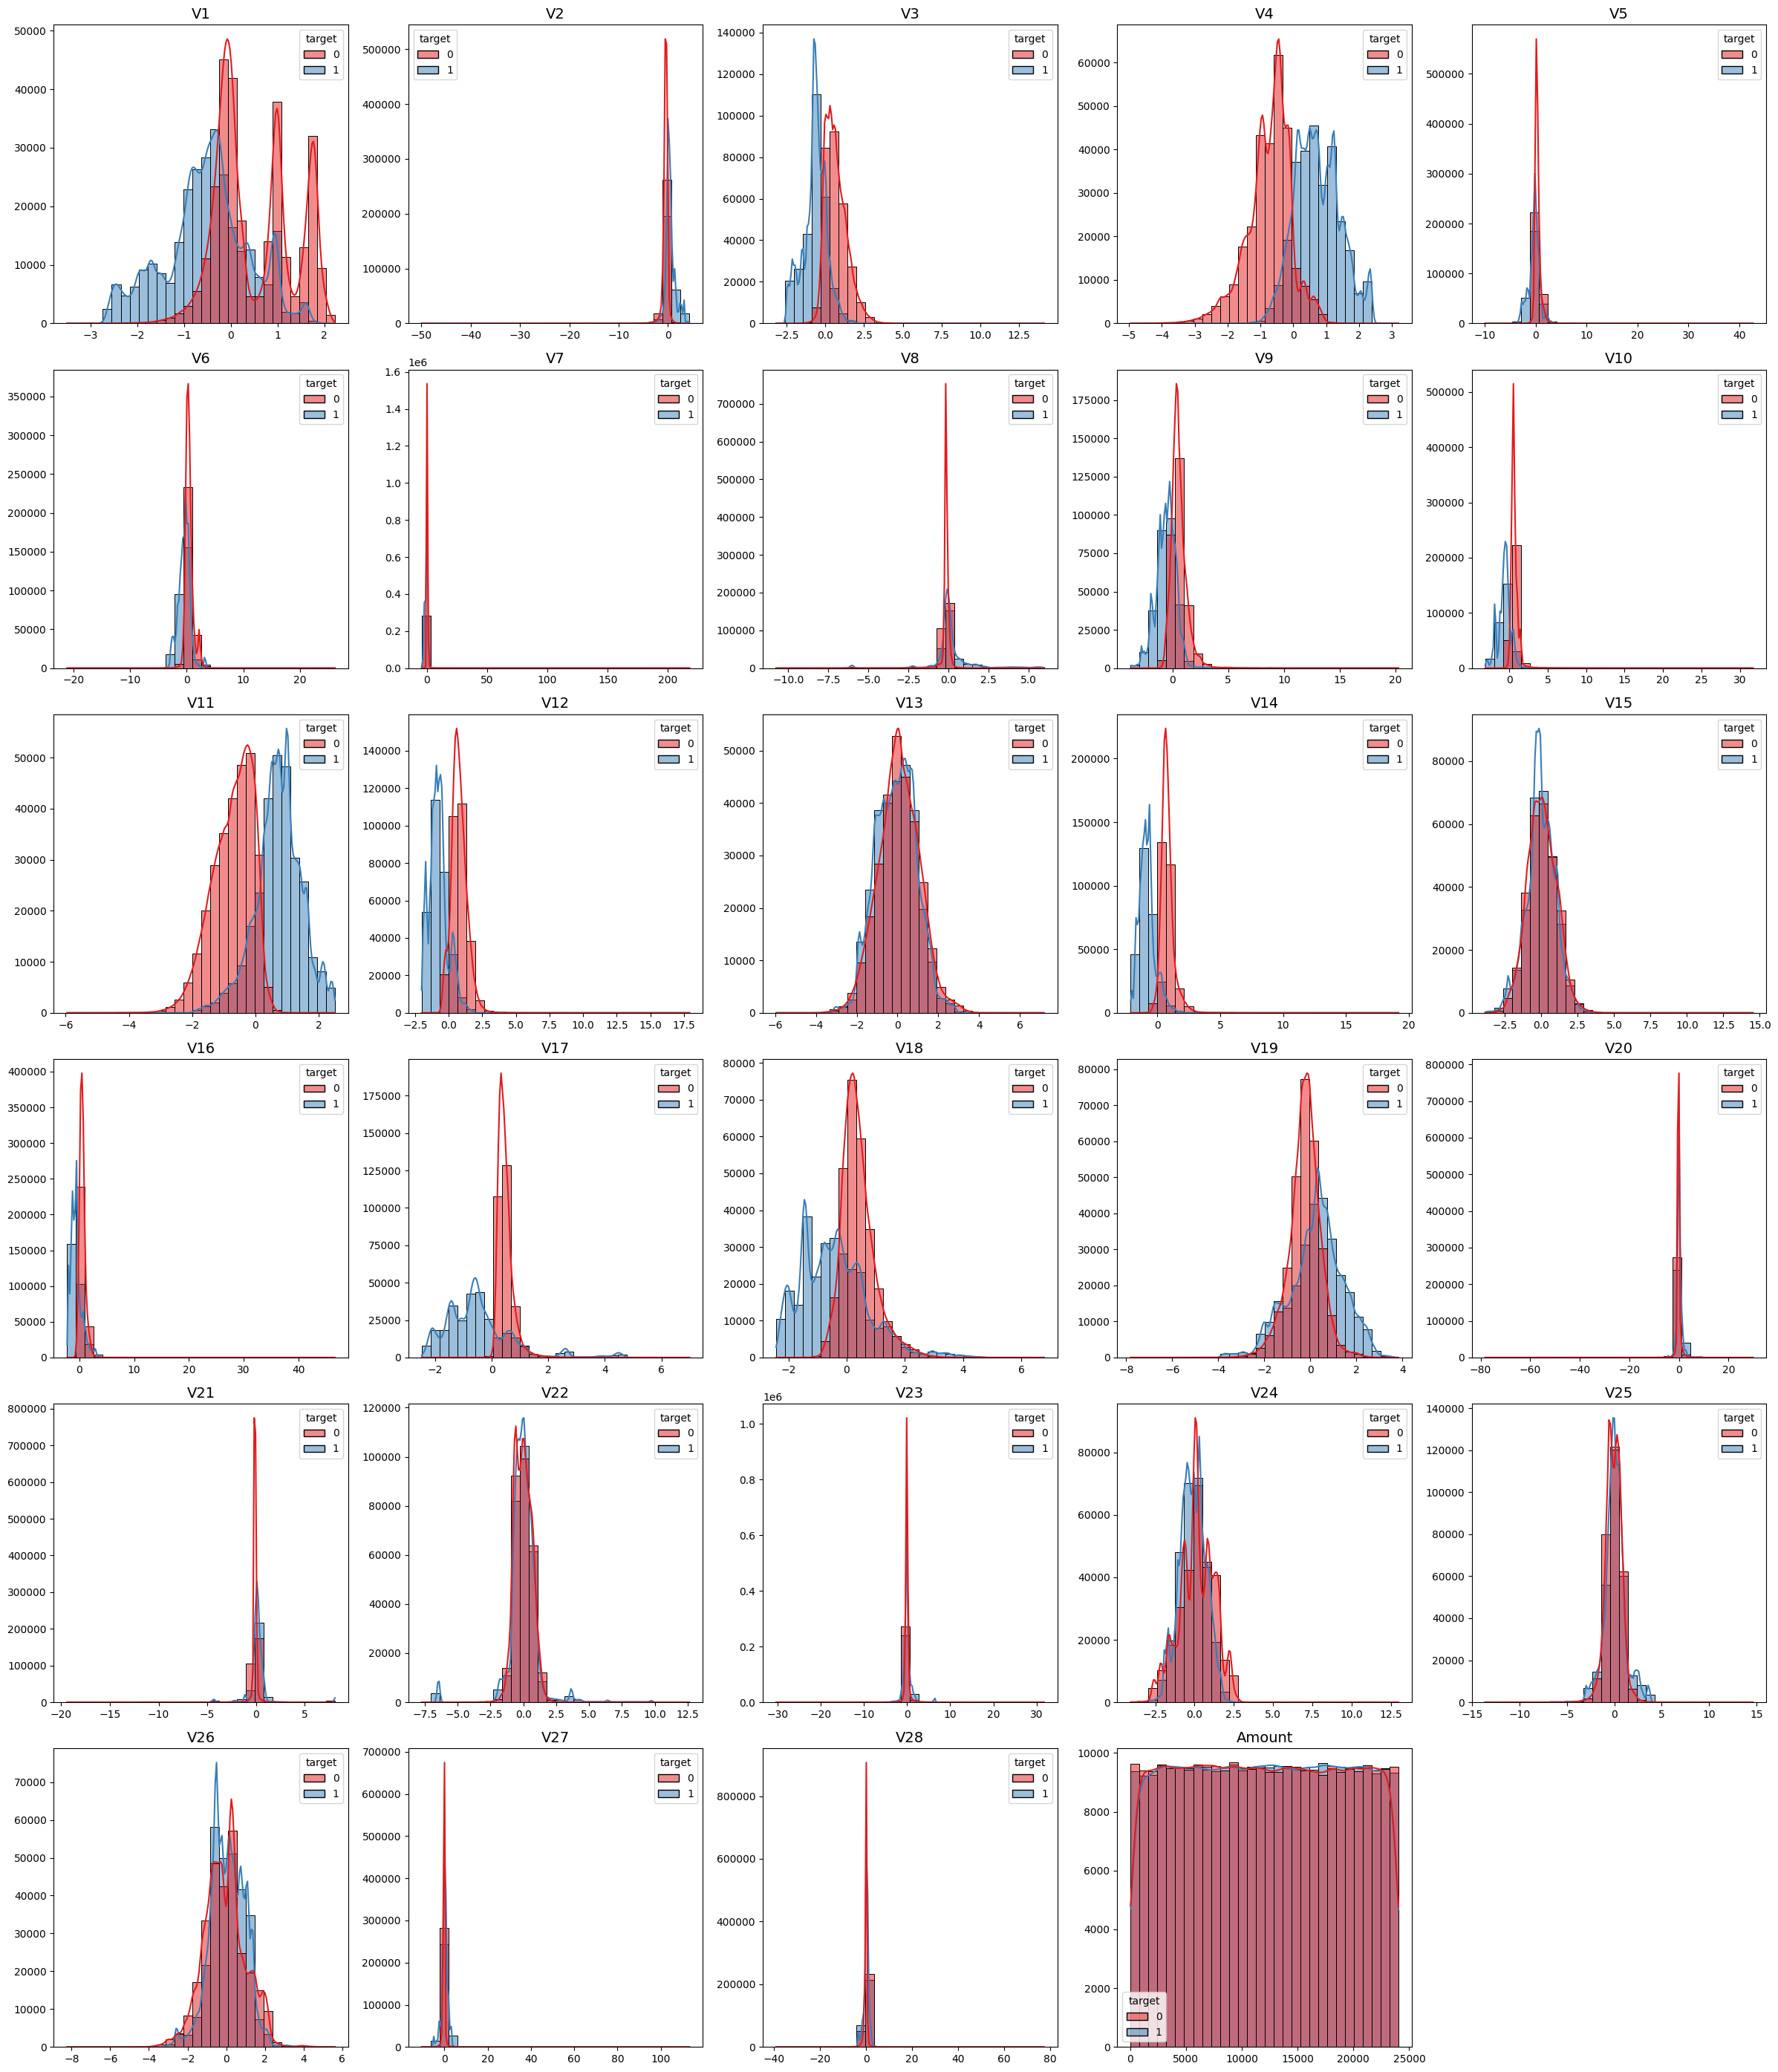

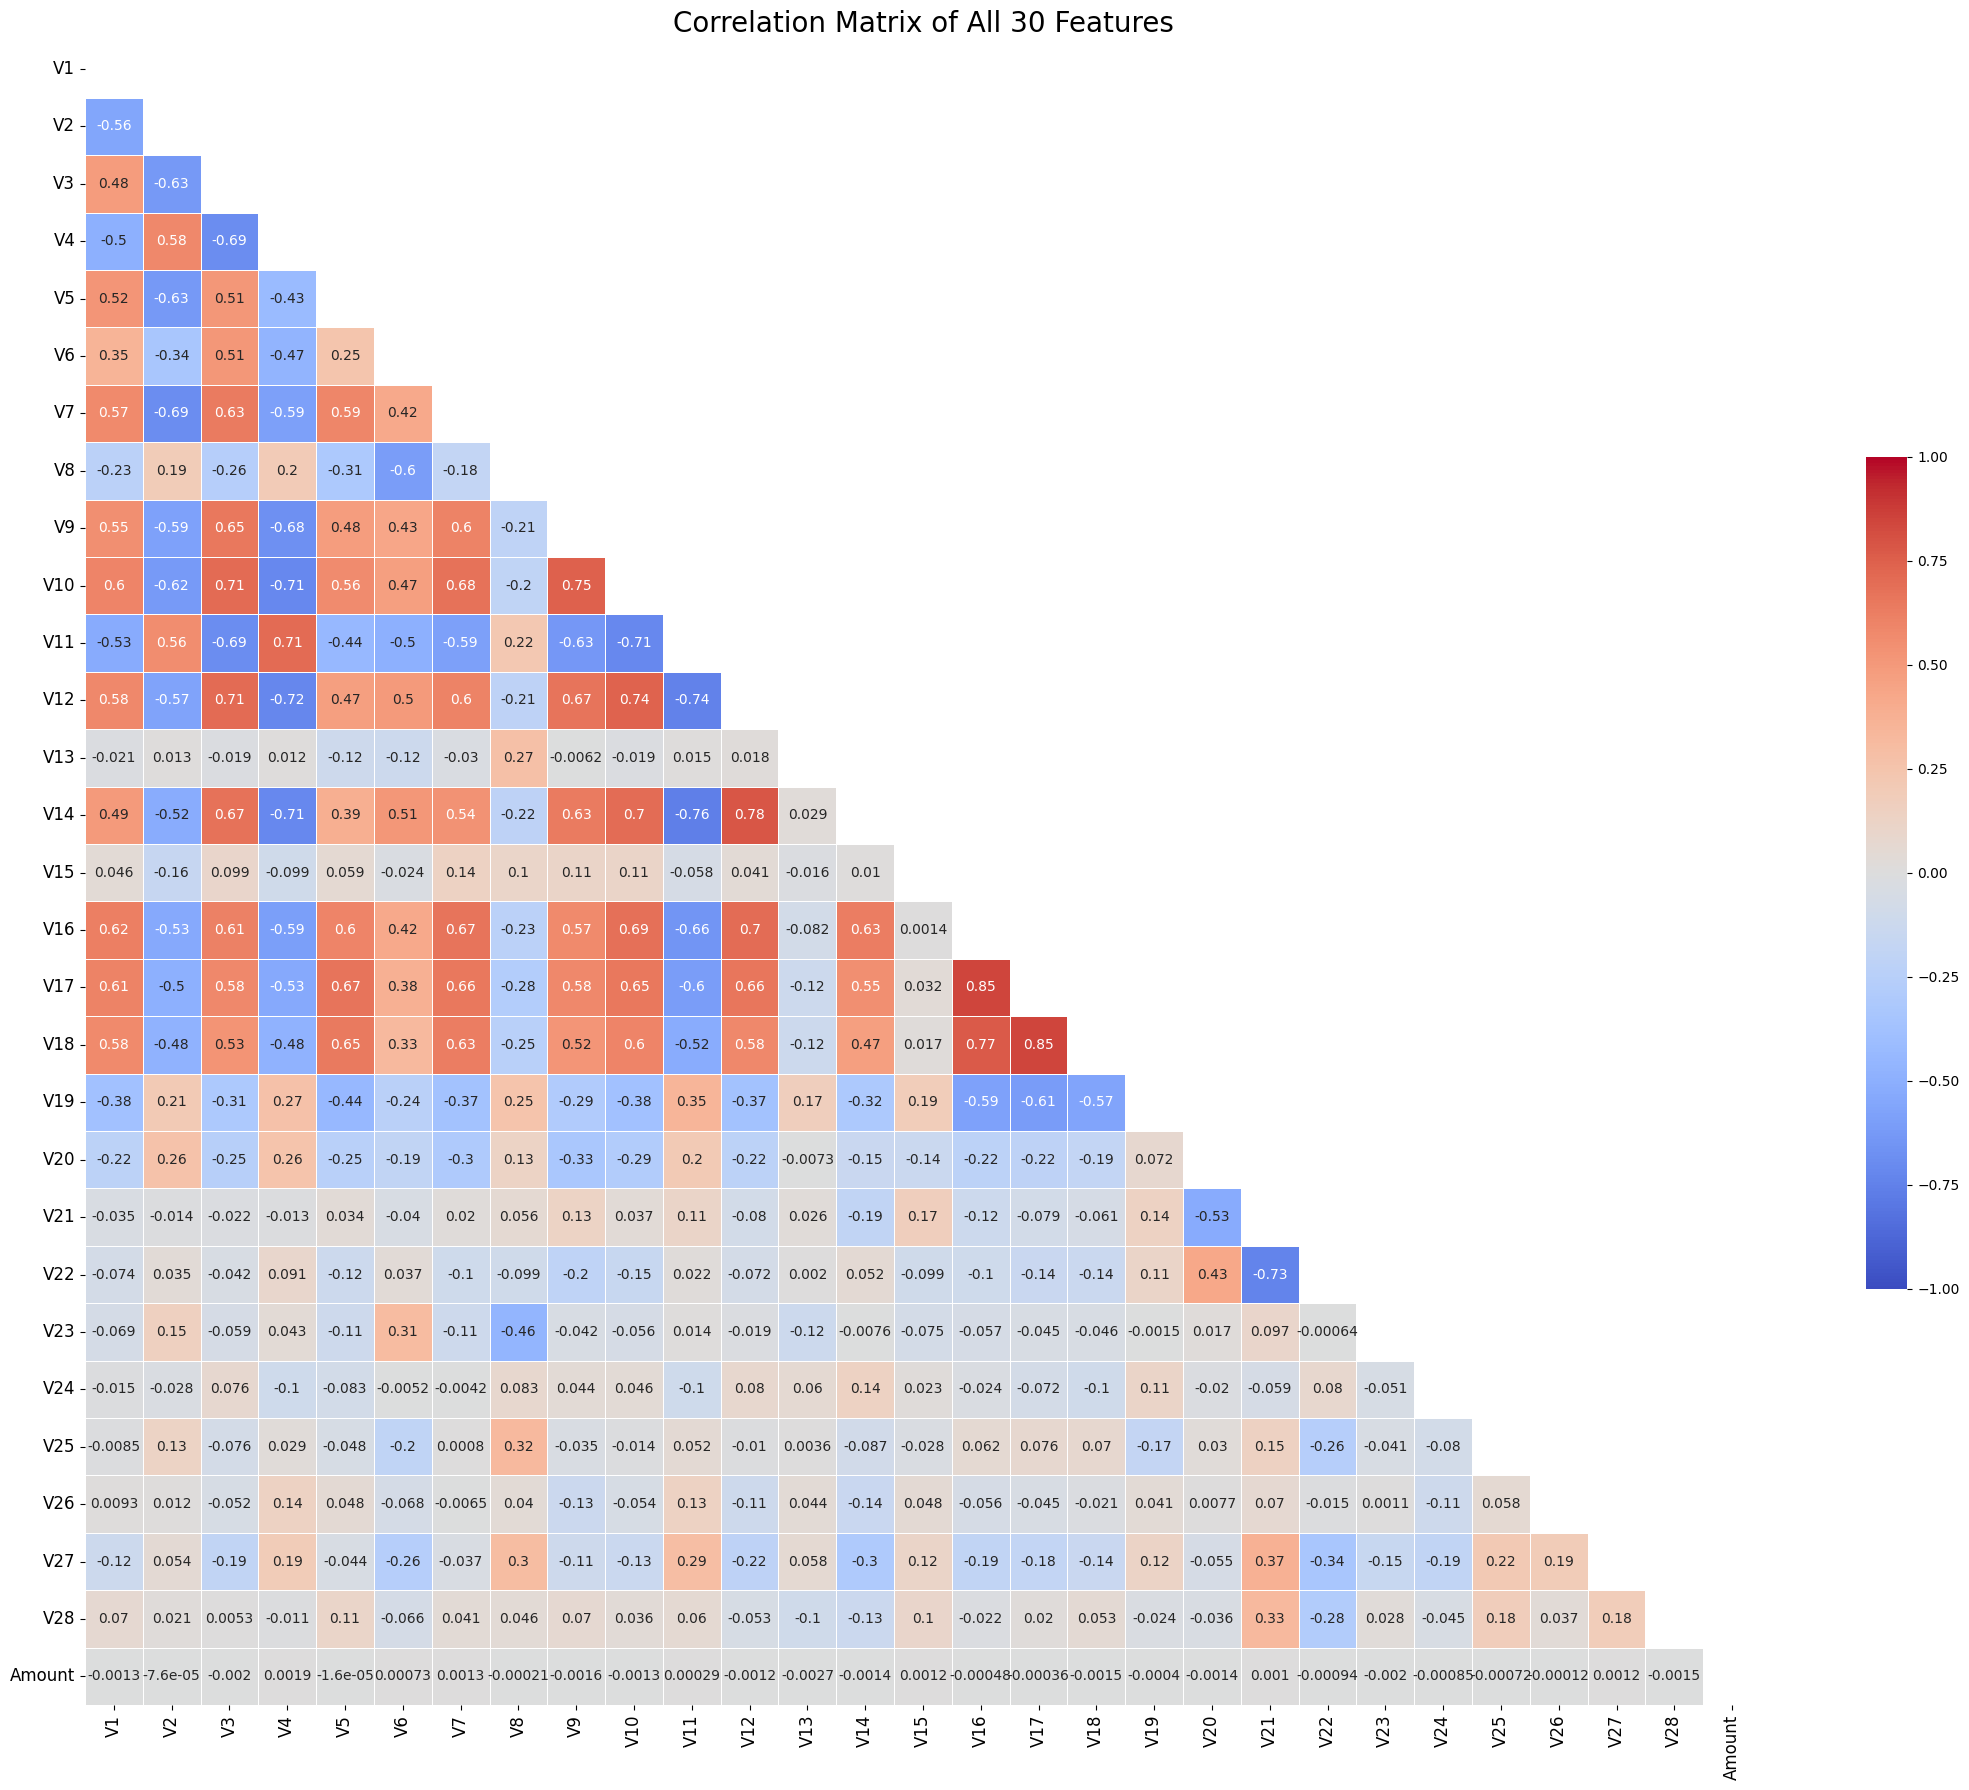

In [7]:
# Summary of df
df_cc_fraud.info()

# Identify missing values
missing_values = df_cc_fraud.isnull().sum().max()
print(f"\nMaximum missing values in any column: {missing_values}")

# Drop non-predective columns
if 'id' in df_cc_fraud.columns:
    df_cc_fraud = df_cc_fraud.drop('id', axis=1)

# Check Class Balance
print(df_cc_fraud['Class'].value_counts(normalize=True))

# Summary Stats for Amount
amount_summary = df_cc_fraud['Amount'].describe()
print("--- Transaction Amount Range Summary ---")
print(f"Minimum: ${amount_summary['min']:.2f}")
print(f"Maximum: ${amount_summary['max']:.2f}")
print(f"Median:  ${amount_summary['50%']:.2f}")
print(f"Mean:    ${amount_summary['mean']:.2f}")
print(f"Range:   ${amount_summary['max'] - amount_summary['min']:.2f}")

amount_summary.to_excel('amount_summary_table.xlsx') # Exporting to Excel

# Define custom color mapping
custom_colors = {0: "seagreen", 1: "salmon"}

# Create the side-by-side boxplots for 'Amount' and 'Class'
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_cc_fraud,
    x='Class',
    y='Amount',
    hue='Class',      # This links the color to the Class
    palette=custom_colors,
    legend=False      # This prevents an unnecessary extra legend
)

# Adjust formatting for readability
plt.title('Transaction Amounts: Legit (0) vs. Fraud (1)')
plt.xlabel('Transaction Class')
plt.ylabel('Amount ($)')
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])

plt.savefig("boxplots.png", bbox_inches='tight', dpi=300) # Exporting to PNG

plt.show()

# Remove Target Variable and Get Features
X = df_cc_fraud.copy()
X.drop(columns=['Class'], inplace=True)
# Get all 29 continuous features
features = [col for col in X.columns]
X.head()

# Assign Target Variable
y = df_cc_fraud['Class']
y.head()

#Combine into one DataFrame for easier analysis
df = X.copy()
df['target'] = y

# Create a 6x5 grid of subplots for Histograms
fig, axes = plt.subplots(6, 5, figsize=(24, 28))
axes = axes.flatten()

# Plot features
for i, col in enumerate(features):
    sns.histplot(
        data=df,
        x=col,
        hue='target',
        kde=True,
        bins=30,
        palette='Set1',
        ax=axes[i],
        alpha=0.5,
    )

    axes[i].set_title(col, fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

plt.savefig("histograms.png", bbox_inches='tight', dpi=300) # Exporting to PNG

plt.show()

# Create Heatmap of Features
corr_matrix = df[features].corr()

# Create a mask to hide the upper triangle (prevents duplicate visual information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure size to accommodate 30 variables
plt.figure(figsize=(22, 18))

# Draw the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": .5})

plt.title('Correlation Matrix of All 30 Features', fontsize=20)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

plt.savefig("correlation_matrix.png", bbox_inches='tight', dpi=300) # Exporting to PNG

plt.show()

## Data Cleaning and Preprocessing

In [8]:
# Downsample to 0.2% fraud for realistic imbalance
legit_df = df_cc_fraud[df_cc_fraud['Class'] == 0]
fraud_df = df_cc_fraud[df_cc_fraud['Class'] == 1]
num_fraud = int((0.002 * len(legit_df)) / 0.998)
df_final = pd.concat([legit_df, fraud_df.sample(n=num_fraud, random_state=42)]).sample(frac=1, random_state=42)

X = df_final.drop('Class', axis=1)
y = df_final['Class']

# Single Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline Scaling (For RF and GBM models only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Preparation for Hybrid Pipeline
iso = IsolationForest(contamination=0.002, random_state=42)
iso.fit(X_train_scaled) # Fit on scaled data for consistency

# Generate Anomaly Scores - decision_function returns the anomaly score (lower = more abnormal)
X_train_scaled['Anomaly_Score'] = iso.decision_function(X_train_scaled)
X_test_scaled['Anomaly_Score'] = iso.decision_function(X_test_scaled)

# Define the StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Random Forest Model Training and Testing

In [ ]:
# Initialize Random Forest with established parameters
# We use the scaled standard features (X_train_scaled) as the baseline comparison
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=2, verbose=1)

# Perform Stratified Cross-Validation to check model stability
print("Running 5-Fold Stratified CV on baseline features...")
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=skf, scoring='average_precision')
print(f"Mean CV AUPRC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# Train on the full scaled training set
rf.fit(X_train_scaled, y_train)

# Predictions and Probabilities
y_pred_rf = rf.predict(X_test_scaled)
y_probs_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Calculate Metrics
rf_auprc = average_precision_score(y_test, y_probs_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

print(f"Final Test AUPRC Score: {rf_auprc:.4f}")

# Generate and Save Confusion Matrix
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
cmn_rf = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis] # Normalized for recall %

sns.heatmap(cmn_rf, annot=True, fmt='.2%', cmap='Blues')
plt.title('Random Forest Baseline: Confusion Matrix')
plt.xticks([0.5, 1.5], ['Pred Legit', 'Pred Fraud'])
plt.yticks([0.5, 1.5], ['Actual Legit', 'Actual Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig("rf_confusion_matrix_baseline.png", bbox_inches='tight', dpi=300)

plt.show()

# Export Baseline Results to Excel
rf_results = pd.DataFrame([{
    'Model': 'Random Forest Baseline',
    'Total Test Samples': len(y_test),
    'Actual Fraud': y_test.sum(),
    'AUPRC Score': rf_auprc,
    'Mean CV AUPRC': rf_cv_scores.mean(),
    'Precision (Fraud)': report_rf['1']['precision'],
    'Recall (Fraud)': report_rf['1']['recall'],
    'F1-Score (Fraud)': report_rf['1']['f1-score']
}])
rf_results.to_excel("rf_baseline_results.xlsx", index=False)

Running 5-Fold Stratified CV on baseline features...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.0min


## Random Forest Model Feature Importance

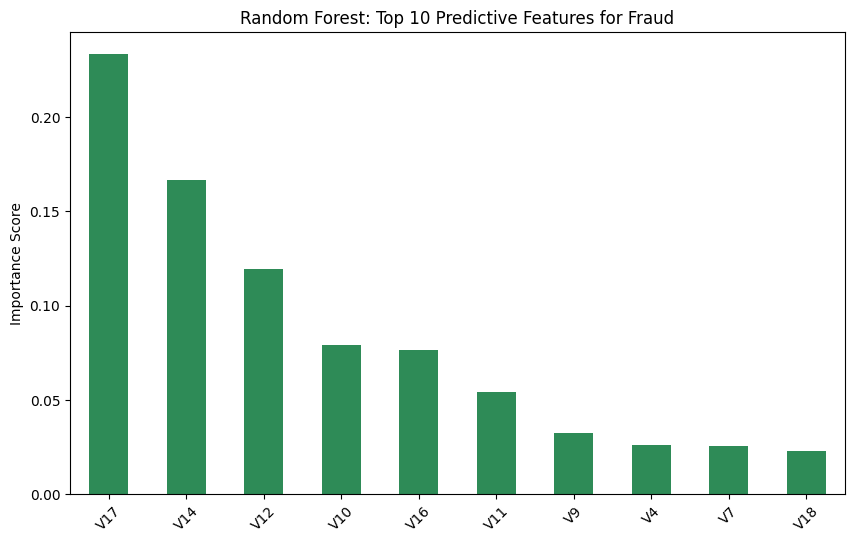

In [15]:
# Extract and store RF importance using the columns from the training set used
rf_importances = pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
rf_importances = rf_importances.sort_values(ascending=False)

# Plot Random Forest Feature Importance
plt.figure(figsize=(10, 6))
rf_importances.head(10).plot(kind='bar', color='seagreen')
plt.title("Random Forest: Top 10 Predictive Features for Fraud")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.savefig("rf_feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()

## XGBoost Model Training and Optimization

In [2]:
# Hyperparameter Optimization (Grid Search)
# Ensure'baseline' is as strong as possible
print("Optimizing GBM hyperparameters via Grid Search...")
param_grid = {'learning_rate': [0.1], 'n_estimators': [100, 200], 'max_depth': [3, 4]}
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='average_precision',
    cv=skf,  # Uses the StratifiedKFold defined in preprocessing
    n_jobs=2
)
grid_search.fit(X_train_scaled, y_train)
gb_best = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

# Performance Validation (Cross-Validation)
print("\nRunning 5-Fold Stratified CV on optimized features...")
cv_scores = cross_val_score(gb_best, X_train_scaled, y_train, cv=skf, scoring='average_precision')
print(f"Mean CV AUPRC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Final Testing & Probability Generation
y_pred_gb = gb_best.predict(X_test_scaled)
y_probs_gb = gb_best.predict_proba(X_test_scaled)[:, 1]

# Calculate Key Metrics
gb_auprc = average_precision_score(y_test, y_probs_gb)
report_gb = classification_report(y_test, y_pred_gb, output_dict=True)
print(f"Final Test AUPRC Score: {gb_auprc:.4f}")

# Threshold Optimization
# Identifying the decision boundary that maximizes the F1-Score
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_gb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold for Optimized GB: {best_threshold:.4f}")

# Visualization: Normalized Confusion Matrix
plt.figure(figsize=(6, 5))
cm_gb = confusion_matrix(y_test, y_pred_gb)
cmn_gb = cm_gb.astype('float') / cm_gb.sum(axis=1)[:, np.newaxis]

sns.heatmap(cmn_gb, annot=True, fmt='.2%', cmap='Blues')
plt.title('Optimized Gradient Boosting: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Pred Legit', 'Pred Fraud'])
plt.yticks([0.5, 1.5], ['Actual Legit', 'Actual Fraud'])

plt.savefig("gb_optimized_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()

# Export Results to Excel
# Storing metrics for the final comparison table
gb_results = pd.DataFrame([{
    'Model': 'Gradient Boosting (Optimized)',
    'Total Test Samples': len(y_test),
    'Actual Fraud': y_test.sum(),
    'AUPRC Score': gb_auprc,
    'Mean CV AUPRC': cv_scores.mean(),
    'Optimal Threshold': best_threshold,
    'Precision (Fraud)': report_gb['1']['precision'],
    'Recall (Fraud)': report_gb['1']['recall'],
    'F1-Score (Fraud)': report_gb['1']['f1-score']
}])
gb_results.to_excel("gb_optimized_results.xlsx", index=False)

Optimizing GBM hyperparameters via Grid Search...


NameError: name 'GridSearchCV' is not defined

## Optimized XGBoost Feature Importance

In [ ]:
# Extract from the best estimator already defined
gb_importances = pd.Series(gb_best.feature_importances_, index=X_train.columns)
gb_importances = gb_importances.sort_values(ascending=False)

# Plot Gradient Boosting Feature Importance
plt.figure(figsize=(10, 6))
gb_importances.head(10).plot(kind='bar', color='royalblue')
plt.title("Gradient Boosting: Top 10 Predictive Features for Fraud")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.savefig("gb_feature_importance_optimized.png", bbox_inches='tight', dpi=300)
plt.show()

## K-Means Clustering Analysis

In [ ]:
# Use the training set for consistency with the model analysis flow
# K-Means is unsupervised, but we use y_train later to see if clusters align with fraud
X_km = X_train.copy()
y_km = y_train.copy()

# Feature Scaling (K-Means is distance-based, so ALL features need scaling)
# We use the scaled training data created in the Preprocessing section
X_scaled_km = X_train_scaled.values

# Finding the Optimal K (Elbow Method)
print("Calculating Elbow Method to find optimal clusters...")
wcss = []
k_range = range(1, 11)
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_km)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='royalblue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)

plt.savefig('kmeans_elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Fit K-Means using K=2 to see if it naturally separates Fraud vs Legit
print("Fitting K-Means with K=2...")
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_km)

# Evaluate Cluster-to-Class Alignment
km_results_df = pd.DataFrame({'Actual_Class': y_km, 'Cluster': clusters})
print("\nCluster vs. Actual Class Distribution:")
cross_tab = pd.crosstab(km_results_df['Actual_Class'], km_results_df['Cluster'],
                        margins=True, margins_name="Total")
print(cross_tab)

# Exporting the crosstab to Excel
cross_tab.to_excel("kmeans_class_distribution.xlsx")

# Visualization using PCA (Reducing 30 features to 2D for plotting)
print("Generating PCA for cluster visualization...")
pca_km = PCA(n_components=2)
X_pca = pca_km.fit_transform(X_scaled_km)

plt.figure(figsize=(14, 6))

# Plot 1: Actual Classes
plt.subplot(1, 2, 1)
plt.scatter(X_pca[y_km == 0, 0], X_pca[y_km == 0, 1], c='seagreen', label='Legit', alpha=0.4, s=15)
plt.scatter(X_pca[y_km == 1, 0], X_pca[y_km == 1, 1], c='salmon', label='Fraud', alpha=0.8, s=40, edgecolors='black')
plt.title('Actual Fraud Labels (PCA-Reduced)')
plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Plot 2: K-Means Clusters
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.4, s=15)
plt.title('K-Means Cluster Assignments (K=2)')
plt.xlabel('PCA Component 1')
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.tight_layout()
plt.savefig('kmeans_pca_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Hybrid: Gradient Boosting with K-Means Feature Engineering

In [ ]:
# Generate K-Means distances
km_hybrid = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
km_hybrid.fit(X_train_scaled.drop(columns=['Anomaly_Score'])) # Drop score so K-Means only looks at raw features

train_distances = km_hybrid.transform(X_train_scaled.drop(columns=['Anomaly_Score']))
test_distances = km_hybrid.transform(X_test_scaled.drop(columns=['Anomaly_Score']))

# Build the super-feature set
# Anomaly_Score is already in X_train_scaled from the step above
X_train_hybrid = X_train_scaled.copy()
X_train_hybrid['Dist_Cluster_0'] = train_distances[:, 0]
X_train_hybrid['Dist_Cluster_1'] = train_distances[:, 1]
X_train_hybrid['Cluster_Label'] = km_hybrid.labels_

X_test_hybrid = X_test_scaled.copy()
X_test_hybrid['Dist_Cluster_0'] = test_distances[:, 0]
X_test_hybrid['Dist_Cluster_1'] = test_distances[:, 1]
X_test_hybrid['Cluster_Label'] = km_hybrid.predict(X_test_scaled.drop(columns=['Anomaly_Score']))

# Train the XGBoost Model
# The model now sees: 30 original features + 2 distances + 1 cluster label + 1 anomaly score
xgb_hybrid.fit(X_train_hybrid, y_train)

# Evaluation
y_probs_hybrid = xgb_hybrid.predict_proba(X_test_hybrid)[:, 1]
y_pred_hybrid = xgb_hybrid.predict(X_test_hybrid)
hybrid_auprc = average_precision_score(y_test, y_probs_hybrid)

print(f"Hybrid XGBoost + K-Means AUPRC: {hybrid_auprc:.4f}")

# Feature Importance: See if the Cluster features actually helped
hybrid_importances = pd.Series(xgb_hybrid.feature_importances_, index=X_train_hybrid.columns)
hybrid_importances = hybrid_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
hybrid_importances.head(10).plot(kind='bar', color='darkorchid')
plt.title("Hybrid Model: Top 10 Features (Including K-Means Distances)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.savefig("hybrid_feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()

# Export Hybrid Results
hybrid_results = pd.DataFrame([{
    'Model': 'Hybrid XGBoost (K-Means Eng)',
    'AUPRC Score': hybrid_auprc,
    'Precision (Fraud)': precision_score(y_test, y_pred_hybrid),
    'Recall (Fraud)': recall_score(y_test, y_pred_hybrid),
    'F1-Score (Fraud)': f1_score(y_test, y_pred_hybrid)
}])
hybrid_results.to_excel("hybrid_model_results.xlsx", index=False)

## Final Performance Metrics Comparison

In [ ]:
# Consolidate results from all model DataFrames
comparison_df = pd.concat([rf_results, gb_results, hybrid_results], ignore_index=True)

# Select the most critical columns for the executive summary
cols_to_keep = ['Model', 'AUPRC Score', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)']
comparison_df = comparison_df[cols_to_keep]

# Display table
print("\nFinal Model Comparison Table:")
print(comparison_df.to_string(index=False))

# Visualization: Bar Plot Comparison of AUPRC
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Model', y='AUPRC Score', palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: Area Under Precision-Recall Curve (AUPRC)')
plt.ylim(0, 1.1)
plt.ylabel('AUPRC Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of the bars for precision
for i, score in enumerate(comparison_df['AUPRC Score']):
    plt.text(i, score + 0.02, f'{score:.4f}', ha='center', fontweight='bold')

plt.savefig("final_model_comparison_auprc.png", bbox_inches='tight', dpi=300)
plt.show()

# Visualization: Precision vs Recall Trade-off
# This shows how well each model balances "Catching Fraud" vs "Accuracy"
melted_df = comparison_df.melt(id_vars='Model', value_vars=['Precision (Fraud)', 'Recall (Fraud)'],
                               var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Trade-off: Precision vs. Recall across Models')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("final_precision_recall_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

# Final Export
comparison_df.to_excel("final_model_performance_report.xlsx", index=False)
print("\nFinal performance report saved to 'final_model_performance_report.xlsx'")